In [1]:
from rdkit import Chem
from rdkit.Chem import rdFingerprintGenerator
import pandas as pd
import numpy as np

def generate_fingerprints(smiles_list, radius=2, fpSize=1024):
    fp_gen = rdFingerprintGenerator.GetMorganGenerator(radius=radius, fpSize=fpSize)
    results = []
    for smiles in smiles_list:
        try:
            mol = Chem.MolFromSmiles(smiles)
            if mol:
                fp_bits = fp_gen.GetFingerprintAsNumPy(mol)
                results.append({
                    'smiles': smiles,
                    'fingerprint': fp_bits
                })
        except:
            continue
    
    return pd.DataFrame(results)
try:
    df = pd.read_csv('herg_num_data.csv')
    
    # 3 сигма 
    # ищу среднее
    mean_value= np.mean(df['pIC50']) 
    print(f'среднее значение pIC50 : {mean_value}') 
    # .теперь ищу среднее отклонение
    std_pIC50= np.std(df['pIC50']) 
    print(f'среднее отклонение от выборки pIC50 : {std_pIC50}') 
    # вычисляю границы левую и правую по данным
    left=mean_value- 3*std_pIC50
    right=mean_value+ 3*std_pIC50
    mask = (df['pIC50'] > left) & (df['pIC50'] < right)
    filtered_df = df[mask]
    
    smiles_list = df['standardized_smiles'].tolist()  
    fingerprint_df = generate_fingerprints(smiles_list)
    fingerprint_df.to_csv('fingerprint_df') 
    if not fingerprint_df.empty:
        print(fingerprint_df) 
        print(f"Всего молекул: {len(fingerprint_df)}")
    else:
        print("Не удалось сгенерировать ни одного фингерпринта")
except Exception as e:
    print(f"Произошла ошибка: {str(e)}")


среднее значение pIC50 : 5.192855927449159
среднее отклонение от выборки pIC50 : 0.8485098231938889
                                                 smiles  \
0     O=C1NCCN1CCN1CCC(c2cn(-c3ccccc3)c3ccc(Cl)cc23)CC1   
1      O=C1NCCN1CCN1CCC(c2cn(C3CCCCC3)c3ccc(Cl)cc23)CC1   
2                CCC(CC)c1cn(-c2ccc(F)cc2)c2ccc(Cl)cc12   
3     O=C1NCCN1CCN1CC=C(c2cn(-c3ccc(F)cc3)c3ccc(Cl)c...   
4                   CC(C)(C)c1ccc2c(ccn2-c2ccc(F)cc2)c1   
...                                                 ...   
9899  N#Cc1ccc(COc2cccc(N3C=NN(Cc4nc5c(F)cc(C(=O)O)c...   
9900  O=C(O)c1cc(F)c2nc(CN3CCN(c4cccc(OCc5ccc(Cl)c6c...   
9901  O=C(O)c1cc(F)c2nc(CN3CCN(c4cccc(OCc5ccc(Cl)c6c...   
9902  COc1cc2c(cc1-c1c(C)noc1C)ncc1[nH]c(=O)n(C(C)c3...   
9903  CCC(=O)N1CCC(Nc2ncnc3c2CN(c2cnc(OC)c(C(F)(F)F)...   

                                            fingerprint  
0     [0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...  
1     [0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...  
2     [0, 1, 0, 0

In [2]:
from sklearn.model_selection import train_test_split 
from sklearn.dummy import DummyRegressor
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
from math import sqrt

# 3 сигма 
# ищу среднее
mean_value= np.mean(df['pIC50']) 
print(f'среднее значение pIC50 : {mean_value}') 
# .теперь ищу среднее отклонение
std_pIC50= np.std(df['pIC50']) 
print(f'среднее отклонение от выборки pIC50 : {std_pIC50}') 
# вычисляю границы левую и правую по данным
left=mean_value- 3*std_pIC50
right=mean_value+ 3*std_pIC50
mask = (df['pIC50'] > left) & (df['pIC50'] < right)
filtered_df = df[mask]

total_molecules = len(df)
filtered_molecules = len(filtered_df)
removed_molecules = total_molecules - filtered_molecules

print(f'было изначально молекул :{total_molecules}')
print(f'молекул после фильтрации: {filtered_molecules}')
print(f'удалено молекул: {removed_molecules}')

fp_array = np.array(fingerprint_df.loc[mask, 'fingerprint'].tolist())
y = filtered_df['pIC50'].values  

X_train, X_test, y_train, y_test = train_test_split(fp_array, y, test_size=0.15, random_state=42)

def get_dummy(model, X_train, y_train, X_test, y_test):

    y_train_predict = model.predict(X_train)
    y_test_predict = model.predict(X_test)
    
    
    train_mse = mean_squared_error(y_true=y_train, y_pred=y_train_predict)
    test_mse = mean_squared_error(y_true=y_test, y_pred=y_test_predict)

    train_rmse = sqrt(train_mse) 
    test_rmse = sqrt(test_mse)
    
    train_r2 = r2_score(y_train, y_train_predict) 
    test_r2 = r2_score(y_test, y_test_predict)
    
    print(f'train MSE {train_mse} train RMSE {train_rmse} train r2 {train_r2}')
    print(f'test_ MSE {test_mse} test_ RMSE {test_rmse} test_ r2 {test_r2}')

    print(f"Train MSE: {train_mse}")
    print(f"Test MSE: {test_mse}")

    
    return {
        'train_pred': y_train_predict,
        'test_pred': y_test_predict,
        'train_mse': train_mse,
        'test_mse': test_mse,
        'train_rmse': train_rmse,
        'test_rmse':test_rmse,
        'train_r2': train_r2,
        'test_r2':test_r2
    }


dummy_regr = DummyRegressor(strategy="mean")
dummy_regr.fit(X_train, y_train)

results = get_dummy(dummy_regr, X_train, y_train, X_test, y_test)

среднее значение pIC50 : 5.192855927449159
среднее отклонение от выборки pIC50 : 0.8485098231938889
было изначально молекул :9904
молекул после фильтрации: 9707
удалено молекул: 197
train MSE 0.5278558578604963 train RMSE 0.7265368936678276 train r2 0.0
test_ MSE 0.5215648930415901 test_ RMSE 0.7221944980693152 test_ r2 -0.000553911143815311
Train MSE: 0.5278558578604963
Test MSE: 0.5215648930415901


Комбинация #1: UMAP=2D, alpha=0.3


C:\Users\user\anaconda3\envs\myenv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
C:\Users\user\anaconda3\envs\myenv\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
C:\Users\user\anaconda3\envs\myenv\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


  Доля кластеризованных: 98.02%, Кластеров: 49

Лучшее соотношение кластеризованных точек: 98.02%
Лучшие параметры UMAP: {'n_components': 2, 'metric': 'euclidean', 'n_neighbors': 15, 'min_dist': 0.1}
Лучшие параметры HDBSCAN: {'min_cluster_size': 30, 'min_samples': 5, 'cluster_selection_epsilon': 0.3}
Лучший alpha: 0.3


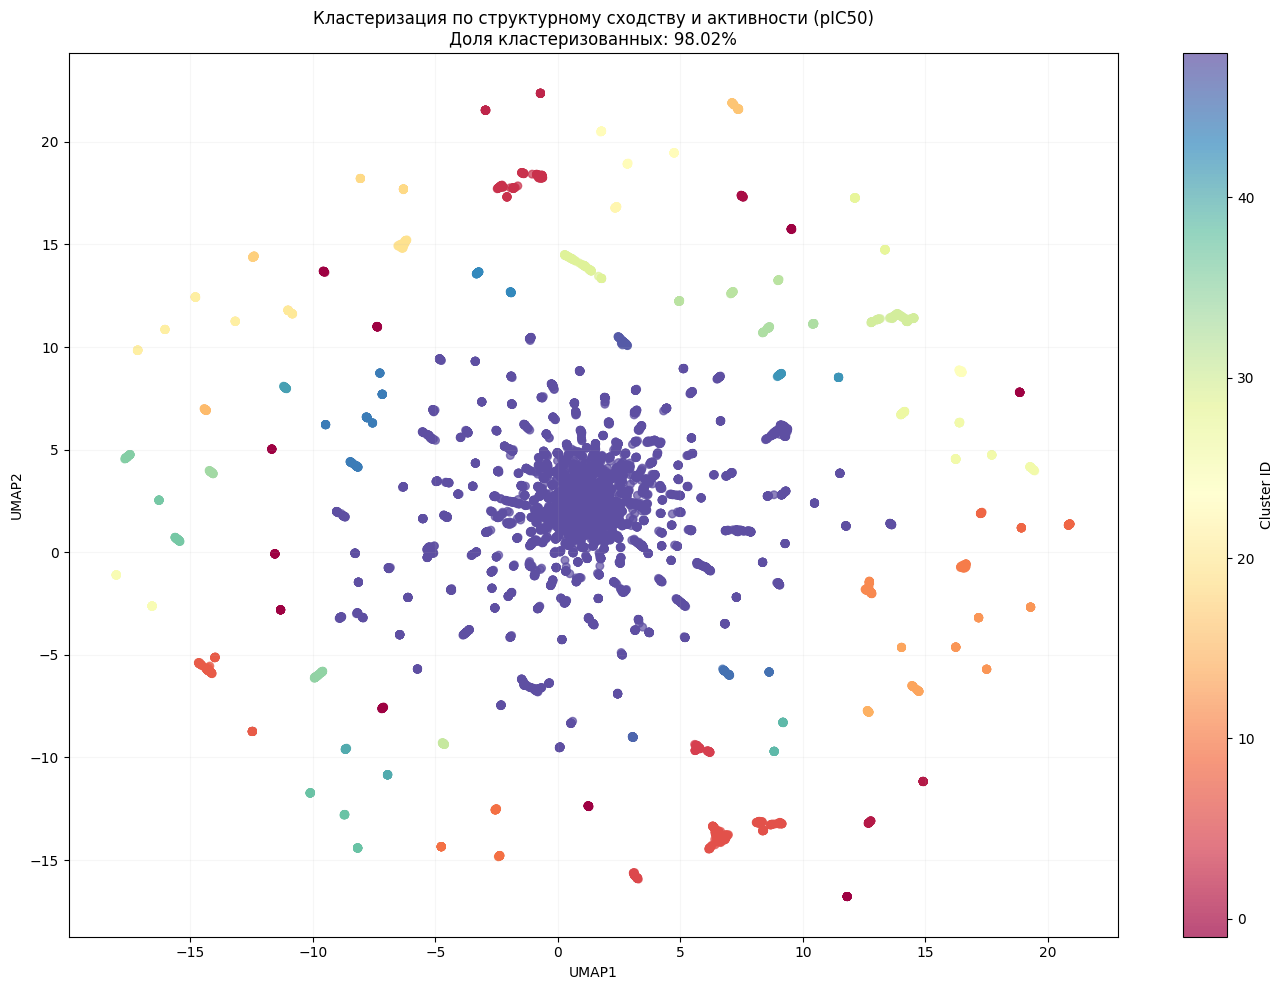

C:\Users\user\AppData\Local\Temp\ipykernel_1284\3922411852.py:108: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


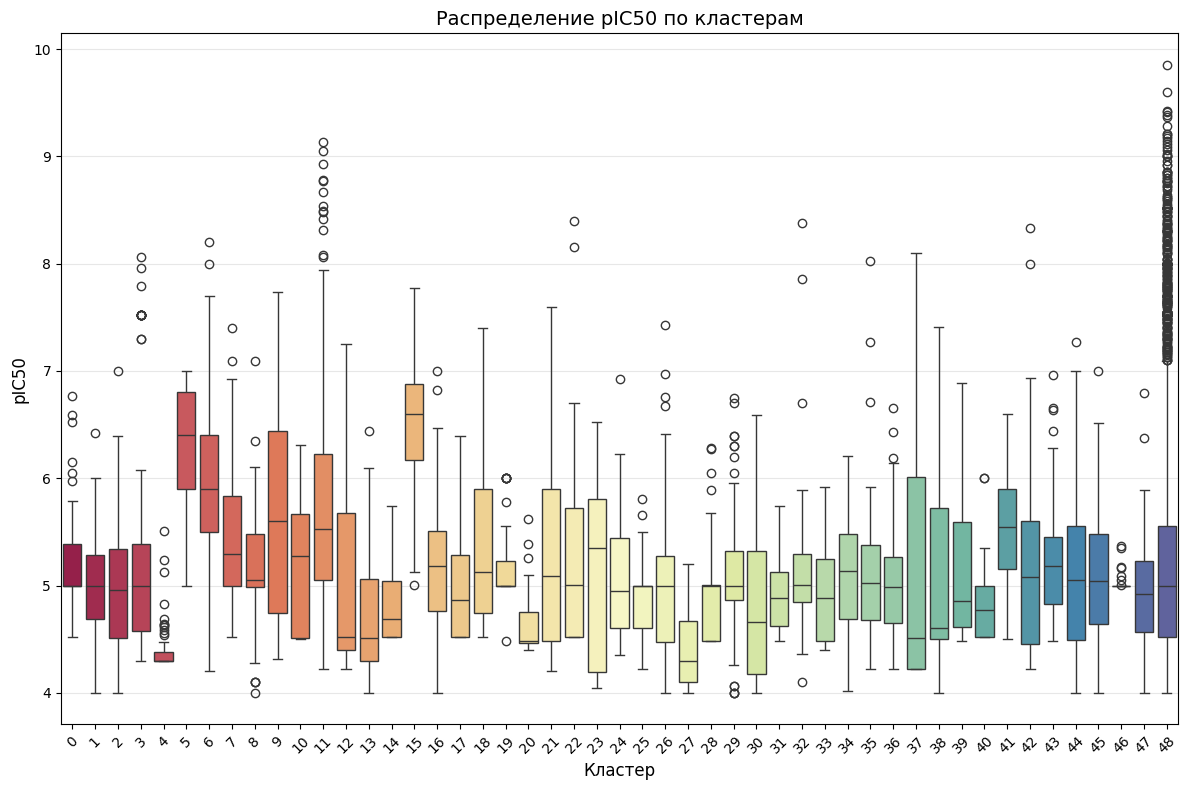


Распределение по кластерам:
Cluster
-1      196
 0       43
 1       42
 2       38
 3      162
 4       70
 5       57
 6      266
 7      149
 8       76
 9       75
 10      69
 11     101
 12      53
 13      44
 14      37
 15      46
 16      48
 17      30
 18      31
 19      86
 20      32
 21      65
 22      37
 23      56
 24      73
 25      35
 26      94
 27      52
 28      40
 29      98
 30     140
 31      41
 32      88
 33      69
 34      39
 35      65
 36      48
 37      65
 38      49
 39      30
 40      39
 41      32
 42      47
 43      59
 44     126
 45      59
 46      33
 47      69
 48    6505
Name: count, dtype: int64

Статистика pIC50 по кластерам:
             mean  count       std
Cluster                           
 15      6.446467     46  0.636271
 5       6.331578     57  0.531224
 6       5.937641    266  0.697829
 11      5.878844    101  1.303857
 9       5.683210     75  0.990581
 41      5.496875     32  0.591599
 7       5.430396    149 

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from umap import UMAP
import hdbscan
from sklearn.preprocessing import StandardScaler
import seaborn as sns



df = pd.read_csv('herg_num_data.csv')

X = np.array(fingerprint_df['fingerprint'].tolist())  
y = df['pIC50'].values.reshape(-1, 1)  
# combined_features = np.hstack([X, alpha * y_scaled]) 

param_grid = {
    'umap': [
        {'n_components': 2, 'metric': 'euclidean', 'n_neighbors': 15, 'min_dist': 0.1},
        {'n_components': 5, 'metric': 'euclidean', 'n_neighbors': 30, 'min_dist': 0.3},
        {'n_components': 10, 'metric': 'euclidean', 'n_neighbors': 60, 'min_dist': 0.0}
    ],
    'hdbscan': [
        {'min_cluster_size': 30, 'min_samples': 5, 'cluster_selection_epsilon': 0.3},
        {'min_cluster_size': 50, 'min_samples': 10, 'cluster_selection_epsilon': 0.5},
        {'min_cluster_size': 20, 'min_samples': 3, 'cluster_selection_epsilon': 0.1}
    ],
    'alpha': [0.3, 0.5, 0.7]  
}

best_params = None
best_cluster_ratio = 0
best_clusters = None
best_embedding = None
stop = False

k = 0
for umap_params in param_grid['umap']:
    for hdbscan_params in param_grid['hdbscan']:
        for alpha in param_grid['alpha']:
            k += 1 
            print(f"Комбинация #{k}: UMAP={umap_params['n_components']}D, alpha={alpha}")
        
            y_scaled = StandardScaler().fit_transform(y)
            combined_features = np.hstack([X, alpha * y_scaled])
            
            umap_model = UMAP(**umap_params, random_state=42)
            X_umap = umap_model.fit_transform(combined_features)

            clusterer = hdbscan.HDBSCAN(**hdbscan_params)
            clusters = clusterer.fit_predict(StandardScaler().fit_transform(X_umap))

            clustered_ratio = np.sum(clusters != -1) / len(clusters)
            n_clusters = len(np.unique(clusters)) - (1 if -1 in clusters else 0)
            
            print(f"  Доля кластеризованных: {clustered_ratio:.2%}, Кластеров: {n_clusters}")

            if clustered_ratio > best_cluster_ratio and clustered_ratio >= 0.7:
                best_cluster_ratio = clustered_ratio
                best_params = {
                    'umap': umap_params, 
                    'hdbscan': hdbscan_params,
                    'alpha': alpha
                }
                best_clusters = clusters
                best_embedding = X_umap
       
                if clustered_ratio > 0.9:
                    stop = True
                    break
            
        if stop:
            break
    if stop:
        break

print(f"\nЛучшее соотношение кластеризованных точек: {best_cluster_ratio:.2%}")
print("Лучшие параметры UMAP:", best_params['umap'])
print("Лучшие параметры HDBSCAN:", best_params['hdbscan'])
print("Лучший alpha:", best_params['alpha'])

plt.figure(figsize=(14, 10))
scatter = plt.scatter(
    best_embedding[:, 0], 
    best_embedding[:, 1], 
    c=best_clusters, 
    cmap='Spectral', 
    s=30, 
    alpha=0.7
)
plt.colorbar(scatter, label='Cluster ID')
plt.title(f"Кластеризация по структурному сходству и активности (pIC50)\nДоля кластеризованных: {best_cluster_ratio:.2%}")
plt.xlabel("UMAP1")
plt.ylabel("UMAP2")
plt.grid(alpha=0.1)
plt.tight_layout()
plt.savefig('best_clustering.png', dpi=300)
plt.show()

if len(np.unique(best_clusters)) > 1:
    cluster_df = pd.DataFrame({
        'Cluster': best_clusters,
        'pIC50': df['pIC50']
    })
    cluster_df = cluster_df[cluster_df['Cluster'] != -1]
    
    plt.figure(figsize=(12, 8))
    sns.boxplot(
        x='Cluster',
        y='pIC50',
        data=cluster_df,
        palette='Spectral'
    )
    plt.title('Распределение pIC50 по кластерам', fontsize=14)
    plt.xlabel('Кластер', fontsize=12)
    plt.ylabel('pIC50', fontsize=12)
    plt.xticks(rotation=45)
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.savefig('pIC50_by_cluster.png', dpi=300)
    plt.show()

output_df = df.copy()
output_df['Cluster'] = best_clusters
if best_embedding.shape[1] >= 2:
    output_df['UMAP1'] = best_embedding[:, 0]
    output_df['UMAP2'] = best_embedding[:, 1]
output_df.to_csv("final_claster.csv", index=False)

cluster_stats = output_df['Cluster'].value_counts().sort_index()
print("\nРаспределение по кластерам:")
print(cluster_stats)

if 'pIC50' in output_df:
    cluster_pIC50 = output_df.groupby('Cluster')['pIC50'].agg(['mean', 'count', 'std'])
    print("\nСтатистика pIC50 по кластерам:")
    print(cluster_pIC50.sort_values('mean', ascending=False))

среднее значение pIC50 : 5.192855927449159
среднее отклонение от выборки pIC50 : 0.8485098231938889
Train size: 8005, Test size: 1702
Лучшие параметры:{'max_depth': 50, 'max_features': 'sqrt', 'n_estimators': 300}
Оценка лучшей модели:
Train MSE: 0.03891861162673594,RMSE: 0.19727800593765119, R²: 0.9255617539455614
Test MSE: 0.2712114927919258,RMSE: 0.5207796969851319, R²: 0.5032969008628945
топ-50 важных битов фингерпринта:
[650 807 767 219 425 893 887 659 765 216 121 158 511 456  64 730 355 747
 175 378 350 653  80 341 564 140 458 695 561 128  33  21 389 116 904   8
 322 428 256 314 875 698 484 842   4 831 218 147 102 301]


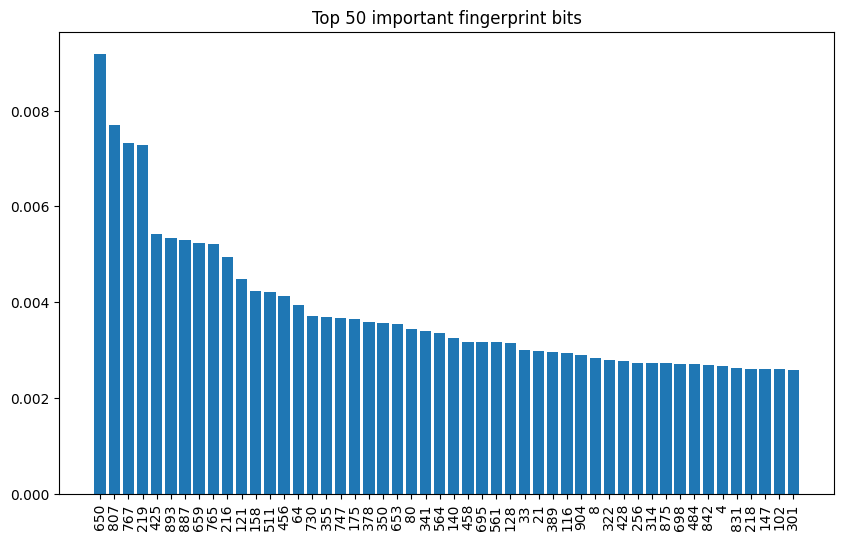

FileNotFoundError: [Errno 2] No such file or directory: 'random_forest_regressor.pkl'

In [4]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV, KFold, train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
from math import sqrt 
import umap.umap_ as umap
import hdbscan
# from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
import pandas as pd
import warnings

# fingerprint_df=pd.read_csv('fingerprint_df') 
df1 = pd.read_csv('final_claster.csv')
# .меня бесило что постоянно выводятся уведомления типо "устаревшая версия бла бла бла" и параметр какой-то его не устраивал
# .короче эти строчки должны быть чтобы код запускался просто без лизних проблем 
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)


df = pd.read_csv('herg_num_data.csv')
# 3 сигма 
# ищу среднее
mean_value= np.mean(df['pIC50']) 
print(f'среднее значение pIC50 : {mean_value}') 
# .теперь ищу среднее отклонение
std_pIC50= np.std(df['pIC50']) 
print(f'среднее отклонение от выборки pIC50 : {std_pIC50}') 
# вычисляю границы левую и правую по данным
left=mean_value- 3*std_pIC50
right=mean_value+ 3*std_pIC50
mask = (df['pIC50'] > left) & (df['pIC50'] < right)
filtered_df = df[mask]



filtered_indices =filtered_df.loc[mask].index.values
fp_array = np.array(fingerprint_df.loc[mask, 'fingerprint'].tolist())
y = filtered_df.loc[filtered_indices, 'pIC50'].values 

X_train, X_test, y_train, y_test = train_test_split(fp_array, y, test_size=0.15, random_state=42)

# новый датафрейм , почему не просто столбец? потому что если вставлять новый столбец и начинать учить моедль, то программа начинает ругаться, что
# ..что индексы не соответствуют, типо там много пустых строк , еще не прошедших через фильтр маску mask + так проще 

cluster_df = pd.DataFrame({
    'smiles': fingerprint_df.loc[mask, 'smiles'],
    'original_index': filtered_indices
})

# обьяснение выбора параметров : 5 измеренеий, потому что так везде написано 
# ..n_jobs=1 если эту строчку не писать то ничего не работает и код выдает ошибку 

reducer = umap.UMAP(
    n_components=5, 
    random_state=42,
    n_jobs=1, 
)

# на этих данных обучается модель и они же сохранятся в массив
the_main_data_array = reducer.fit_transform(fp_array)

# крастеризация hdbscan
# почему минимальное количество точек для кластера 5? потому что.
clusterer = hdbscan.HDBSCAN(min_cluster_size=5, gen_min_span_tree=True)
clusters = clusterer.fit_predict(the_main_data_array)

cluster_df['cluster'] = clusters

# тестовыя и тренировочная выборки
train_indices = []
test_indices = []
# .1158 точек включены в выборку (даже если они шумовые данные то есть-1) 
for cluster_id in np.unique(clusters):
    cluster_data = cluster_df[cluster_df['cluster'] == cluster_id]
    cluster_idx = cluster_data.index
    if len(cluster_idx) > 1:
        clust_train, clust_test = train_test_split(
            cluster_idx, test_size=0.15, random_state=42
        )
        train_indices.extend(cluster_df.loc[clust_train, 'original_index'].values)
        test_indices.extend(cluster_df.loc[clust_test, 'original_index'].values)
    elif len(cluster_idx) == 1:  # Точечные кластеры и шум
        train_indices.extend(cluster_df.loc[cluster_idx, 'original_index'].values)


# создание финальных выборок с использованием оригинальных индексов
# Функция .isin() проверяет, содержится ли каждое значение из столбца DataFrame в указанном списке/массиве.
# Возвращает булев массив (True/False) той же длины, что и исходный столбец.
X_train = fp_array[cluster_df['original_index'].isin(train_indices)]
X_test = fp_array[cluster_df['original_index'].isin(test_indices)]
y_train = y[cluster_df['original_index'].isin(train_indices)]
y_test = y[cluster_df['original_index'].isin(test_indices)]

# вывод размерностей
print(f"Train size: {len(X_train)}, Test size: {len(X_test)}")
#


# здесь старая часть
rf_model = RandomForestRegressor(random_state=42, n_jobs=-1)

# GridSearchCV с кросс-валидацией
param_grid = {
    'n_estimators': range(50, 501, 50), 
    'max_depth': [5, 10, 20, 30, 40, 50],
    'max_features': ['sqrt', 'log2']
}

grid_search = GridSearchCV(
    estimator=rf_model,
    param_grid=param_grid,
    cv=KFold(n_splits=5,shuffle=True, random_state=42),
    scoring='r2', 
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print(f"Лучшие параметры:{ grid_search.best_params_}")
best_rf = grid_search.best_estimator_

def evaluate_model(model, X_train, y_train, X_test, y_test):
    for name, X, y in [("Train", X_train, y_train),
                       ("Test", X_test, y_test)]:
        y_pred = model.predict(X)
        mse = mean_squared_error(y, y_pred)
        rmse = sqrt(mse) 
        r2 = r2_score(y, y_pred)
        print(f"{name} MSE: {mse},RMSE: {rmse}, R²: {r2}")
 
print("Оценка лучшей модели:")
evaluate_model(best_rf, X_train, y_train, X_test, y_test)
importances = best_rf.feature_importances_
top_ind = np.argsort(importances)[-50:][::-1]
print("топ-50 важных битов фингерпринта:")
print(top_ind)

plt.figure(figsize=(10, 6))
plt.bar(range(50), importances[top_ind])
plt.xticks(range(50), top_ind, rotation=90)
plt.title("Top 50 important fingerprint bits")
plt.show()

